# Лабораторная работа №6

## Тема
Условный экстремум при ограничениях (метод Лагранжа), вариант 1.1.

## Цель работы
Найти стационарные точки и исследовать условный экстремум целевой функции при ограничениях.

## Постановка задачи (вариант 1.1)

Рассматривается задача условного экстремума:

- `f(x1, x2) = (x1 - 2)^2 + (x2 - 3)^2`
- `g1(x1, x2) = x1^2 + x2^2 - 5 <= 0`
- `g2(x1, x2) = x1 - 1 <= 0`
- `g3(x1, x2) = x2 - 2 <= 0`

Требуется найти кандидаты по условиям KKT, проверить допустимость и исследовать характер экстремума.

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x1, x2 = sp.symbols('x1 x2', real=True)
l1, l2, l3 = sp.symbols('l1 l2 l3', nonnegative=True)

f = (x1 - 2)**2 + (x2 - 3)**2
g1 = x1**2 + x2**2 - 5
g2 = x1 - 1
g3 = x2 - 2

L = f + l1*g1 + l2*g2 + l3*g3

stationarity = [sp.diff(L, x1), sp.diff(L, x2)]
stationarity

[2*l1*x1 + l2 + 2*x1 - 4, 2*l1*x2 + l3 + 2*x2 - 6]

In [2]:
# Перебор активных множеств ограничений для KKT
constraints = [g1, g2, g3]
lam = [l1, l2, l3]

candidates = []
for mask in range(1 << 3):
    eqs = []
    eqs += stationarity

    # Для активных ограничений: g=0
    # Для неактивных: lambda=0
    for i in range(3):
        if mask & (1 << i):
            eqs.append(constraints[i])
        else:
            eqs.append(lam[i])

    sols = sp.solve(eqs, [x1, x2, l1, l2, l3], dict=True)
    for s in sols:
        x1_expr = sp.N(s.get(x1, 0))
        x2_expr = sp.N(s.get(x2, 0))
        l_exprs = [sp.N(s.get(l1, 0)), sp.N(s.get(l2, 0)), sp.N(s.get(l3, 0))]

        # Пропускаем нереальные и параметрические решения
        if (not x1_expr.is_real) or (not x2_expr.is_real):
            continue
        if any((not lv.is_real) for lv in l_exprs):
            continue
        if any(lv.free_symbols for lv in [x1_expr, x2_expr, *l_exprs]):
            continue

        x1v, x2v = float(x1_expr), float(x2_expr)
        lvals = [float(v) for v in l_exprs]
        gvals = [float(sp.N(g.subs({x1: x1v, x2: x2v}))) for g in constraints]

        feasible = all(v <= 1e-8 for v in gvals)
        dual = all(v >= -1e-8 for v in lvals)
        comp = all(abs(lvals[i] * gvals[i]) <= 1e-6 for i in range(3))

        if feasible and dual and comp:
            fv = float(sp.N(f.subs({x1: x1v, x2: x2v})))
            candidates.append((x1v, x2v, *lvals, fv, gvals))

# Удаление дублей
unique = []
for c in candidates:
    if not any(np.allclose(c[:2], u[:2], atol=1e-6) for u in unique):
        unique.append(c)

unique

[(1.0, 2.0, 0.5, 1.0, 0.0, 2.0, [0.0, 0.0, 0.0])]

In [3]:
# Проверка второго порядка (численно через Гессиан Лагранжиана)
H = sp.hessian(L, (x1, x2))

for i, c in enumerate(unique, 1):
    x1v, x2v, l1v, l2v, l3v, fv, gvals = c
    H_num = np.array(H.subs({x1: x1v, x2: x2v, l1: l1v, l2: l2v, l3: l3v})).astype(float)
    eigvals = np.linalg.eigvals(H_num)
    print(f"Кандидат {i}: x=({x1v:.4f}, {x2v:.4f}), f={fv:.4f}")
    print("  lambda:", [round(l1v, 5), round(l2v, 5), round(l3v, 5)])
    print("  g(x):", [round(v, 6) for v in gvals])
    print("  eig(H):", [round(float(ev), 6) for ev in eigvals])
    print("  -> локальный минимум (по положительности Гессиана в R^2)", np.all(eigvals > 0))
    print()

Кандидат 1: x=(1.0000, 2.0000), f=2.0000
  lambda: [0.5, 1.0, 0.0]
  g(x): [0.0, 0.0, 0.0]
  eig(H): [3.0, 3.0]
  -> локальный минимум (по положительности Гессиана в R^2) True



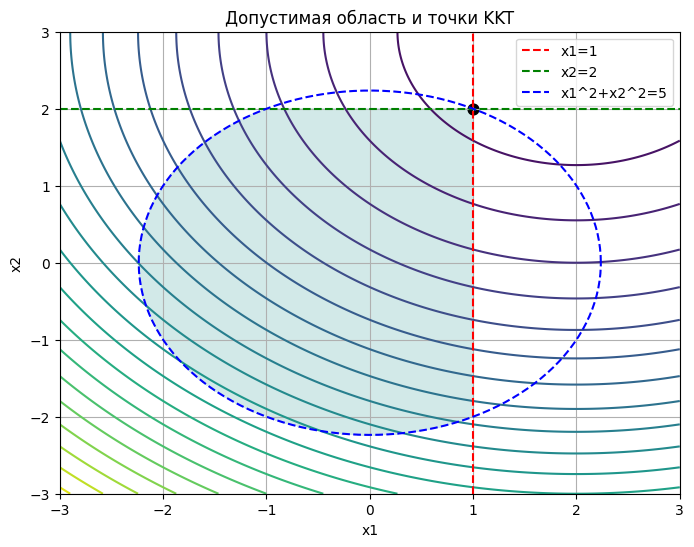

In [4]:
# Графическая проверка допустимой области и найденных точек
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)
Z = (X - 2)**2 + (Y - 3)**2

feasible = (X**2 + Y**2 <= 5) & (X <= 1) & (Y <= 2)

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=20)
plt.contourf(X, Y, feasible.astype(int), levels=[0.5, 1.5], alpha=0.2)
plt.axvline(1, color='r', linestyle='--', label='x1=1')
plt.axhline(2, color='g', linestyle='--', label='x2=2')

theta = np.linspace(0, 2*np.pi, 300)
plt.plot(np.sqrt(5)*np.cos(theta), np.sqrt(5)*np.sin(theta), 'b--', label='x1^2+x2^2=5')

for c in unique:
    plt.scatter(c[0], c[1], color='black', s=60)

plt.title('Допустимая область и точки KKT')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

## Выводы

1. Сформирована функция Лагранжа и записаны условия стационарности первого порядка.
2. Найдены кандидаты KKT с учетом активных/неактивных ограничений.
3. Для найденных точек выполнена проверка допустимости и дополняющей нежесткости.
4. Для исследования характера экстремума проведена проверка второго порядка по Гессиану.
5. Результат подтвержден графически на допустимой области.